In [1]:
import os
os.getcwd()

'/home/jovyan/steph_codes/notebook'

In [2]:
from pyspark.sql import SparkSession, DataFrame  # type: ignore
from pyspark.sql.functions import (
    col, input_file_name, lit, trim, regexp_replace, when, to_date  # type: ignore
)
from pyspark.sql.types import StringType, DateType  # type: ignore
import azfr_fsspec_utils as fspath 
import azfr_fsspec_abfs

import pandas as pd
import numpy as np

from typing import Iterable, Optional

# Configure Azure connection
azfr_fsspec_abfs.use()

# Create Spark session
spark = SparkSession.builder \
    .appName("PTF_MVT_Column_Discovery") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

print(f"✓ Spark {spark.version} initialized")
print(f"✓ Azure connection configured")

Picked up JAVA_TOOL_OPTIONS: -Dhttp.proxyHost=squid-proxy.azfr-infra.svc.cluster.local -Dhttps.proxyHost=squid-proxy.azfr-infra.svc.cluster.local -Dhttp.proxyPort=3128 -Dhttps.proxyPort=3128 -Dhttp.nonProxyHosts=localhost|127.0.0.1|169.254.169.254|1.241.7.180|*.local|*.svc|*.allianz|*.vault.azure.net|github.developer.allianz.io|1.240.147.248|1.240.50.38|1.240.144.247|1.240.187.25|1.240.70.1|1.240.105.41|1.240.0.1|azfrdatalakedev.blob.core.windows.net|azfrdatalakedev.dfs.core.windows.net|azfrdatalakeqa.blob.core.windows.net|azfrdatalakeqa.dfs.core.windows.net|azfrdatalakeprod.blob.core.windows.net|azfrdatalakeprod.dfs.core.windows.net|azfrdatalab.blob.core.windows.net|azfrdatalab.dfs.core.windows.net|azfrfinancedev.blob.core.windows.net|azfrfinancedev.dfs.core.windows.net|azfrfinanceqa.blob.core.windows.net|azfrfinanceqa.dfs.core.windows.net|azfrfinanceprod.blob.core.windows.net|azfrfinanceprod.dfs.core.windows.net|azfrdatalakehealthdev.blob.core.windows.net|azfrdatalakehealthdev.dfs.co

✓ Spark 3.5.7 initialized
✓ Azure connection configured


# Helpers

In [3]:
# Configuration
DATALAKE_BASE = "abfss://shared@azfrdatalab.dfs.core.windows.net/ABR/P4D/ADC/DATAMARTS/CONSTRUCTION"
VISION = "202601"
YEAR = VISION[:4]
MONTH = VISION[4:6]

bronze_month_path = f"{DATALAKE_BASE}/bronze/{YEAR}/{MONTH}"
bronze_ref_path = f"{DATALAKE_BASE}/bronze/ref"
MONTHLY_PATH = f"{DATALAKE_BASE}/silver/{YEAR}/{MONTH}"
gold_path = f"{DATALAKE_BASE}/gold/{YEAR}/{MONTH}"

print(f"Monthly: {MONTHLY_PATH}")

Monthly: abfss://shared@azfrdatalab.dfs.core.windows.net/ABR/P4D/ADC/DATAMARTS/CONSTRUCTION/silver/2026/01


In [4]:
def read_and_clean_csv_pandas(path, sep="|", encoding="LATIN9"):
    """
    Read CSV with pandas, lowercase column names,
    and replace SAS-style nulls (".", "", " ", weird spaces) with NaN
    only in string/object columns.
    """

    # Read CSV
    df = pd.read_csv(path, sep=sep, dtype=str, encoding=encoding)  # read as str first (safe for cleaning)

    # Lowercase column names (like your Spark step)
    df.columns = df.columns.str.lower()

    # Identify string/object columns
    string_cols = df.select_dtypes(include="object").columns

    if len(string_cols) == 0:
        return df

    # Clean SAS nulls
    for c in string_cols:
        df[c] = (
            df[c]
            .str.replace("\u00A0", " ", regex=False)  # replace weird space
            .str.strip()                             # trim spaces
            .replace({".": None, "": None, " ": None})
        )

    return df

In [5]:
def compare_nopol_presence(
    sas_df: pd.DataFrame,
    python_df: pd.DataFrame,
    nopol_col: str = "nopol",
):
    """
    Compare SAS vs Python on policy numbers (nopol).

    Returns:
        - in_both      : polices présentes dans les deux
        - only_in_sas  : polices présentes seulement dans SAS
        - only_in_py   : polices présentes seulement dans Python
    """

    # Ensure same type (important!)
    sas_nopol = sas_df[nopol_col].astype(str)
    py_nopol  = python_df[nopol_col].astype(str)

    sas_set = set(sas_nopol)
    py_set  = set(py_nopol)

    in_both = sas_set.intersection(py_set)
    only_in_sas = sas_set - py_set
    only_in_py  = py_set - sas_set

    # Convert to DataFrames (easier to inspect/export)
    df_both = pd.DataFrame({nopol_col: sorted(in_both)})
    df_only_sas = pd.DataFrame({nopol_col: sorted(only_in_sas)})
    df_only_py = pd.DataFrame({nopol_col: sorted(only_in_py)})

    return df_both, df_only_sas, df_only_py

def print_nopol_comparison(both, only_sas, only_py, nopol_col="nopol", max_show=10):
    """
    Pretty print results of nopol presence comparison.
    """

    total_common = len(both)
    total_only_sas = len(only_sas)
    total_only_py = len(only_py)

    print("\n" + "="*90)
    print("POLICY NUMBER (NOPOL) CONSISTENCY CHECK — SAS vs PYTHON")
    print("="*90)

    print(f"Polices présentes dans SAS ET Python : {total_common}")
    print(f"Polices présentes seulement dans SAS : {total_only_sas}")
    print(f"Polices présentes seulement dans Python : {total_only_py}")

    print("\n" + "-"*90)

    if total_only_sas > 0:
        print("POLICES MANQUANTES DANS PYTHON (présentes dans SAS mais absentes en Python):")
        print(only_sas.head(max_show).to_string(index=False))
        if total_only_sas > max_show:
            print(f"... (+{total_only_sas - max_show} autres)")
    else:
        print("Aucune police manquante dans Python")

    print("\n" + "-"*90)

    if total_only_py > 0:
        print("POLICES EN TROP DANS PYTHON (absentes dans SAS):")
        print(only_py.head(max_show).to_string(index=False))
        if total_only_py > max_show:
            print(f"... (+{total_only_py - max_show} autres)")
    else:
        print("Aucune police en trop dans Python")

    print("\n" + "="*90)

    # Final verdict
    if total_only_sas == 0 and total_only_py == 0:
        print("VERDICT: SAS et Python sont STRICTEMENT ALIGNÉS sur les polices.")
    else:
        print("VERDICT: DÉSYNCHRONISATION détectée entre SAS et Python.")
        print("Il faut investiguer les filtres, jointures ou règles métier.")

    print("="*90 + "\n")

# Comparaison KPI ptf_mvt

In [6]:
ptf_mvt = f"{gold_path}/ptf_mvt_{VISION}"

df_mvt  = spark.read.format("delta").load(ptf_mvt)

print(f"PTF MVT Columns: {[c for c in df_mvt.columns]} \n\nSize : {len(df_mvt.columns)}")

PTF MVT Columns: ['nopol', 'dircom', 'noint', 'cdpole', 'cdprod', 'cmarch', 'cseg', 'cssseg', 'nopolli1', 'dtcrepol', 'posacta_ri', 'rueacta_ri', 'cediacta_ri', 'mois_echeance', 'jour_echeance', 'dtresilp', 'dttraar', 'cdnatp', 'cdsitp', 'ptgst', 'cdreg', 'cdgecent', 'mtca', 'cdnaf', 'cdtre', 'cdcoass', 'coass', 'top_coass', 'type_affaire', 'primes_ptf_intemp', 'primes_ptf_100_intemp', 'part_cie', 'primes_ptf', 'nbptf', 'expo_ytd', 'expo_gli', 'top_temp', 'cdmotres', 'cdcasres', 'cdpolrvi', 'vision', 'exevue', 'moisvue', 'noclt', 'nmclt', 'cdfract', 'quarisq', 'nmrisq', 'nmsrisq', 'resrisq', 'ruerisq', 'lidirisq', 'posrisq', 'vilrisq', 'nbafn', 'nbres', 'nbafn_anticipe', 'nbres_anticipe', 'primes_afn', 'primes_res', 'upper_mid', 'dt_deb_expo', 'dt_fin_expo', 'segment2', 'type_produit_2', 'ctdeftra', 'dstcsc', 'dtouchan', 'dtrectrx', 'dtrcppr', 'lbqltsou', 'dteffan', 'dttraan', 'actprin', 'ctprvtrv', 'mtsmpr', 'lbnattrv', 'top_revisable', 'critere_revision', 'cdgrev', 'nbrpt', 'nbrpc', 

In [7]:
df_mvt_py = df_mvt.toPandas()
df_mvt_py.head()

26/02/18 18:51:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,nopol,dircom,noint,cdpole,cdprod,cmarch,cseg,cssseg,nopolli1,dtcrepol,...,hazard_grades_fire,hazard_grades_bi,hazard_grades_rca,hazard_grades_rce,hazard_grades_trc,hazard_grades_rcd,hazard_grades_do,isic_code_gbl,top_berlioz,top_partenariat
0,57829859,AZ,400242,1,00539,6,2,1,54245310,2016-01-01,...,None,None,None,None,None,None,None,439000,0,0
1,58720340,AZ,109556,1,01099,6,2,9,46617155,2017-12-01,...,None,None,None,None,None,None,None,432923,0,0
2,36391762,AZ,400362,1,00548,6,2,1,None,2001-12-10,...,None,None,None,None,None,None,None,170221,0,0
3,36391703,AZ,400362,1,00543,6,2,2,None,2001-12-10,...,None,None,None,None,None,None,None,410001,0,0
4,36391895,AZ,400362,1,00003,6,2,5,None,2001-12-10,...,None,None,None,None,None,None,None,410001,0,0


In [8]:
sas_mvt_path = f"sas_datas/{VISION}/mvt_ptf{VISION}.csv"
df_mvt_sas = read_and_clean_csv_pandas(sas_mvt_path)
df_mvt_sas.head()

,nopol,dircom,noint,cdpole,cdprod,cmarch,cseg,cssseg,nopolli1,dtcrepol,...,hazard_grades_fire,hazard_grades_bi,hazard_grades_rca,hazard_grades_rce,hazard_grades_trc,hazard_grades_rcd,hazard_grades_do,isic_code_gbl,top_berlioz,top_partenariat
0,B72025249,AZEC,21663,3,RBA,6,2,3,B72025249,01/01/1999,...,None,None,None,None,None,None,None,None,None,None
1,G00549714,AZEC,40192,3,RCC,6,2,3,G00549714,01/01/1986,...,None,None,None,None,None,None,None,None,None,None
2,B72043608,AZEC,21663,3,RCD,6,2,1,B72043608,01/01/1999,...,None,None,None,None,None,None,None,None,None,None
3,B72682539,AZEC,21663,3,RCD,6,2,1,B72682539,01/01/1999,...,None,None,None,None,None,None,None,None,None,None
4,G10005811,AZEC,25094,3,RCC,6,2,3,G10005811,25/06/1996,...,None,None,None,None,None,None,None,None,None,None


In [9]:
df_mvt_py.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83773 entries, 0 to 83772
Columns: 110 entries, nopol to top_partenariat
dtypes: float64(16), int32(14), object(80)
memory usage: 65.8+ MB


In [10]:
df_mvt_sas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83773 entries, 0 to 83772
Columns: 110 entries, nopol to top_partenariat
dtypes: object(110)
memory usage: 70.3+ MB


In [11]:
def kpi_by_cdprod_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replicates the PySpark KPI aggregation:
      groupBy(cdprod) + count(nopol) + sums(...) + orderBy(cdprod)

    Notes:
    - count_of_nopol = count of non-null nopol (same behavior as Spark count(col))
    - sums ignore NaNs by default in pandas (like Spark sum ignoring nulls)
    """
    needed = [
        "cdprod", "nopol", "mtca", "nbptf", "nbafn", "nbres", "primes_afn", "primes_res"
    ]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Ensure numeric columns are numeric (safe if already numeric)
    num_cols = ["mtca", "nbptf", "nbafn", "nbres", "primes_afn", "primes_res"]
    tmp = df.copy()

    for c in num_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    out = (
        tmp.groupby("cdprod", dropna=False)
        .agg(
            count_of_nopol=("nopol", "count"),
            sum_of_mtca1=("mtca", "sum"),
            sum_of_nbptf=("nbptf", "sum"),
            sum_of_nbafn=("nbafn", "sum"),
            sum_of_nbres=("nbres", "sum"),
            sum_of_primes_afn=("primes_afn", "sum"),
            sum_of_primes_res=("primes_res", "sum"),
        )
        .reset_index()
        .sort_values("cdprod", kind="mergesort")
        .reset_index(drop=True)
    )

    return out

In [12]:
py_kpi = kpi_by_cdprod_pandas(df_mvt_py)
py_kpi.head(py_kpi.shape[0])

,cdprod,count_of_nopol,sum_of_mtca1,sum_of_nbptf,sum_of_nbafn,sum_of_nbres,sum_of_primes_afn,sum_of_primes_res
0,00003,4284,0.000000e+00,0,34,0,495511.0,0.0
1,00023,14,9.877610e+05,13,0,1,0.0,10482.0
2,00024,466,2.311861e+06,428,13,30,1039822.0,989615.0
3,00149,6,0.000000e+00,6,0,0,0.0,0.0
4,00519,20,5.820900e+06,17,0,2,0.0,14147.0
5,00522,7,0.000000e+00,0,0,0,0.0,0.0
6,00525,2,0.000000e+00,1,0,1,0.0,10056.0
7,00526,12,4.993600e+05,10,0,1,0.0,11886.0
8,00531,2,9.500000e+03,1,0,1,0.0,17009.0
9,00533,1,0.000000e+00,1,0,0,0.0,0.0


In [13]:
sas_kpi = kpi_by_cdprod_pandas(df_mvt_sas)
sas_kpi.head(sas_kpi.shape[0])

,cdprod,count_of_nopol,sum_of_mtca1,sum_of_nbptf,sum_of_nbafn,sum_of_nbres,sum_of_primes_afn,sum_of_primes_res
0,00003,4284,0.000000e+00,0,34,0,495511.54,0.00
1,00023,14,9.877610e+05,13,0,1,0.00,10482.24
2,00024,466,2.311861e+06,428,13,30,1039822.31,989613.64
3,00149,6,0.000000e+00,6,0,0,0.00,0.00
4,00519,20,5.820900e+06,17,0,2,0.00,14147.37
5,00522,7,0.000000e+00,0,0,0,0.00,0.00
6,00525,2,0.000000e+00,1,0,1,0.00,10056.01
7,00526,12,4.993600e+05,10,0,1,0.00,11886.44
8,00531,2,9.500000e+03,1,0,1,0.00,17008.60
9,00533,1,0.000000e+00,1,0,0,0.00,0.00


In [14]:
def diff_kpi_tables(
    python_kpi: pd.DataFrame,
    sas_kpi: pd.DataFrame,
    key: str = "cdprod",
    kpi_cols: Optional[Iterable[str]] = None,
    how: str = "outer",
    fill_value: float = 0.0,
    sort: bool = True,
) -> pd.DataFrame:
    """
    Build a pure difference table (python - sas) for KPI tables.

    Parameters
    ----------
    python_kpi : pd.DataFrame
        KPI table produced by Python/Spark (already aggregated).
    sas_kpi : pd.DataFrame
        KPI table produced by SAS (already aggregated).
    key : str
        Join key column (default: 'cdprod').
    kpi_cols : iterable[str] | None
        KPI columns to diff. If None, uses the intersection of columns minus the key.
    how : str
        Merge type (default: 'outer') to keep all keys from both sides.
    fill_value : float
        Value to replace missing KPI values after merge (default: 0.0).
    sort : bool
        Sort output by key (default: True).

    Returns
    -------
    pd.DataFrame
        A dataframe with [key] + KPI columns, where each KPI column is (python - sas).
    """
    if key not in python_kpi.columns or key not in sas_kpi.columns:
        raise ValueError(f"Key '{key}' must exist in both dataframes.")

    # Determine KPI columns
    if kpi_cols is None:
        common_cols = sorted(
            set(python_kpi.columns).intersection(sas_kpi.columns) - {key}
        )
    else:
        kpi_cols = list(kpi_cols)
        missing_py = [c for c in kpi_cols if c not in python_kpi.columns]
        missing_sas = [c for c in kpi_cols if c not in sas_kpi.columns]
        if missing_py or missing_sas:
            raise ValueError(f"Missing columns. python missing={missing_py}, sas missing={missing_sas}")
        common_cols = kpi_cols

    # Merge
    merged = python_kpi[[key] + common_cols].merge(
        sas_kpi[[key] + common_cols],
        on=key,
        how=how,
        suffixes=("_python", "_sas"),
    )

    # Fill missing so diffs are computable
    for c in common_cols:
        merged[f"{c}_python"] = pd.to_numeric(merged[f"{c}_python"], errors="coerce").fillna(fill_value)
        merged[f"{c}_sas"]    = pd.to_numeric(merged[f"{c}_sas"], errors="coerce").fillna(fill_value)

    # Build diff-only table
    diff_df = pd.DataFrame({key: merged[key]})
    for c in common_cols:
        diff_df[c] = merged[f"{c}_python"] - merged[f"{c}_sas"]

    if sort:
        diff_df = diff_df.sort_values(key).reset_index(drop=True)

    return diff_df

In [15]:
diff_df = diff_kpi_tables(
    python_kpi=py_kpi,
    sas_kpi=sas_kpi,
    key="cdprod"
)

diff_df.head(diff_df.shape[0])

,cdprod,count_of_nopol,sum_of_mtca1,sum_of_nbafn,sum_of_nbptf,sum_of_nbres,sum_of_primes_afn,sum_of_primes_res
0,00003,0,0.0,0,0,0,-0.54,0.00
1,00023,0,0.0,0,0,0,0.00,-0.24
2,00024,0,0.0,0,0,0,-0.31,1.36
3,00149,0,0.0,0,0,0,0.00,0.00
4,00519,0,0.0,0,0,0,0.00,-0.37
5,00522,0,0.0,0,0,0,0.00,0.00
6,00525,0,0.0,0,0,0,0.00,-0.01
7,00526,0,0.0,0,0,0,0.00,-0.44
8,00531,0,0.0,0,0,0,0.00,0.40
9,00533,0,0.0,0,0,0,0.00,0.00


In [16]:
both, only_sas, only_py = compare_nopol_presence(
    sas_df=df_mvt_sas,
    python_df=df_mvt_py,
    nopol_col="nopol"
)

print_nopol_comparison(both, only_sas, only_py)


POLICY NUMBER (NOPOL) CONSISTENCY CHECK — SAS vs PYTHON
Polices présentes dans SAS ET Python : 83773
Polices présentes seulement dans SAS : 0
Polices présentes seulement dans Python : 0

------------------------------------------------------------------------------------------
Aucune police manquante dans Python

------------------------------------------------------------------------------------------
Aucune police en trop dans Python

VERDICT: SAS et Python sont STRICTEMENT ALIGNÉS sur les polices.



In [ ]:
import pandas as pd

def nb_polices_par_groupe(df: pd.DataFrame, group_col: str, nopol_col: str = "nopol") -> pd.DataFrame:
    out = (
        df.dropna(subset=[group_col, nopol_col])
          .groupby(group_col)[nopol_col]
          .nunique()
          .reset_index(name="nb_polices")
          .sort_values(pgroup_col)
          .reset_index(drop=True)
    )
    return out

def compare_nb_polices_sas_python(
    df_sas: pd.DataFrame,
    df_py: pd.DataFrame,
    group_col: str = "cdpole",
    nopol_col: str = "nopol"
) -> pd.DataFrame:
    """
    Produit un tableau: group_col | SAS | PYTHON
    où SAS/PYTHON = nb de polices distinctes (nopol uniques) par groupe.
    """
    sas = nb_polices_par_groupe(df_sas, group_col=group_col, nopol_col=nopol_col).rename(columns={"nb_polices": "SAS"})
    py  = nb_polices_par_groupe(df_py,  group_col=group_col, nopol_col=nopol_col).rename(columns={"nb_polices": "PYTHON"})

    comp = sas.merge(py, on=group_col, how="outer").fillna(0)

    # en int
    comp["SAS"] = comp["SAS"].astype(int)
    comp["PYTHON"] = comp["PYTHON"].astype(int)

    return comp.sort_values(group_col).reset_index(drop=True)

table_polices = compare_nb_polices_sas_python(
    df_sas=df_mvt_sas,
    df_py=df_mvt_py,     # ou df_mvt_pyspark.toPandas()
    group_col="cdpole",
    nopol_col="nopol"
)

table_polices

,cdpole,SAS,PYTHON
0,1,29669,29669
1,3,54104,54104


# EMISSIONS - EMISSIONS_POL_GARP

In [18]:
pol_garp = f"{gold_path}/primes_emises_{VISION}_pol_garp"

df_pol_garp  = spark.read.format("delta").load(pol_garp)

print(f"EMISSIONS_POL_GARP Columns: {[c for c in df_pol_garp.columns]} \n\nSize : {len(df_pol_garp.columns)}")

EMISSIONS_POL_GARP Columns: ['vision', 'dircom', 'cdpole', 'nopol', 'cdprod', 'noint', 'cgarp', 'cmarch', 'cseg', 'cssseg', 'cd_cat_min', 'primes_x', 'primes_n', 'mtcom_x'] 

Size : 14


In [19]:
df_pol_garp_py = df_pol_garp.toPandas()
df_pol_garp_py.head()

,vision,dircom,cdpole,nopol,cdprod,noint,cgarp,cmarch,cseg,cssseg,cd_cat_min,primes_x,primes_n,mtcom_x
0,202601,AZ,1,60918171,00539,275130,010,6,2,1,282,695.24,695.24,204.65
1,202601,AZ,1,53367856,01054,109188,010,6,2,6,282,742.10,742.10,148.42
2,202601,AZ,1,57219729,01054,H94109,999,6,2,6,999,0.00,0.00,0.00
3,202601,AZ,1,59886655,01054,109834,010,6,2,6,282,33.22,33.22,4.99
4,202601,AZ,1,62157538,01054,H91354,010,6,2,6,282,1190.11,1190.11,238.02


In [20]:
sas_pol_garp_path = f"sas_datas/{VISION}/primes_emises{VISION}_pol_garp.csv"
df_pol_garp_sas = read_and_clean_csv_pandas(sas_pol_garp_path)
df_pol_garp_sas.head()

,vision,dircom,cdpole,nopol,cdprod,noint,cgarp,cmarch,cseg,cssseg,cd_cat_min,primes_x,primes_n,mtcom_x
0,202601,AZ,1,0214250017,00543,H97446,101,6,2,2,351,2683.9,None,402.59
1,202601,AZ,1,0214250017,00543,H97446,111,6,2,2,352,427.87,None,64.18
2,202601,AZ,1,0214250017,00543,H97446,250,6,2,2,351,50,None,7.5
3,202601,AZ,1,045545719,01074,H96009,020,6,2,6,363,223.31,223.31,44.66
4,202601,AZ,1,045545719,01074,H96009,041,6,2,6,364,1038.18,1038.18,207.64


In [21]:
df_pol_garp_py.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148509 entries, 0 to 148508
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   vision      148509 non-null  object 
 1   dircom      148509 non-null  object 
 2   cdpole      148509 non-null  object 
 3   nopol       148509 non-null  object 
 4   cdprod      148509 non-null  object 
 5   noint       148509 non-null  object 
 6   cgarp       148509 non-null  object 
 7   cmarch      148509 non-null  object 
 8   cseg        148509 non-null  object 
 9   cssseg      148509 non-null  object 
 10  cd_cat_min  148509 non-null  object 
 11  primes_x    145066 non-null  float64
 12  primes_n    148509 non-null  float64
 13  mtcom_x     147703 non-null  float64
dtypes: float64(3), object(11)
memory usage: 15.9+ MB


In [22]:
df_pol_garp_sas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148509 entries, 0 to 148508
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   vision      148509 non-null  object
 1   dircom      148509 non-null  object
 2   cdpole      148509 non-null  object
 3   nopol       148509 non-null  object
 4   cdprod      148509 non-null  object
 5   noint       148509 non-null  object
 6   cgarp       148509 non-null  object
 7   cmarch      148509 non-null  object
 8   cseg        148509 non-null  object
 9   cssseg      148509 non-null  object
 10  cd_cat_min  148509 non-null  object
 11  primes_x    148509 non-null  object
 12  primes_n    146078 non-null  object
 13  mtcom_x     148509 non-null  object
dtypes: object(14)
memory usage: 15.9+ MB


In [23]:
def kpi_by_cdprod_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replicates the PySpark KPI aggregation
    """
    needed = [
        "cdprod", "nopol", "primes_x", "primes_n", "mtcom_x"
    ]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Ensure numeric columns are numeric (safe if already numeric)
    num_cols = ["nopol", "primes_x", "primes_n", "mtcom_x"]
    tmp = df.copy()

    for c in num_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    out = (
        tmp.groupby("cdprod", dropna=False)
        .agg(
            count_of_nopol=("nopol", "count"),
            sum_of_primes_x=("primes_x", "sum"),
            sum_of_primes_n=("primes_n", "sum"),
            sum_of_mtcom_x=("mtcom_x", "sum"),
        )
        .reset_index()
        .sort_values("cdprod", kind="mergesort")
        .reset_index(drop=True)
    )

    return out

In [24]:
result_pol_garp_py = kpi_by_cdprod_pandas(df_pol_garp_py)
result_pol_garp_py.head()

,cdprod,count_of_nopol,sum_of_primes_x,sum_of_primes_n,sum_of_mtcom_x
0,00003,421,56349.69,11757.69,31288.39
1,00023,35,1792.26,1792.26,4204.23
2,00024,2288,418537.56,566949.56,158601.97
3,00149,3,675.48,675.48,128.42
4,00519,44,2068.53,2216.51,2794.85


In [25]:
result_pol_garp_sas = kpi_by_cdprod_pandas(df_pol_garp_sas)
result_pol_garp_sas.head()

,cdprod,count_of_nopol,sum_of_primes_x,sum_of_primes_n,sum_of_mtcom_x
0,00003,421,582059.73,120586.34,77111.50
1,00023,35,42711.38,42711.38,8268.74
2,00024,2288,7347886.08,4895889.06,933715.08
3,00149,3,675.48,675.48,128.42
4,00519,44,157186.10,157186.10,25254.96


In [26]:
both, only_sas, only_py = compare_nopol_presence(
    sas_df=df_pol_garp_sas,
    python_df=df_pol_garp_py,
    nopol_col="nopol"
)

print_nopol_comparison(both, only_sas, only_py)


POLICY NUMBER (NOPOL) CONSISTENCY CHECK — SAS vs PYTHON
Polices présentes dans SAS ET Python : 20452
Polices présentes seulement dans SAS : 0
Polices présentes seulement dans Python : 0

------------------------------------------------------------------------------------------
Aucune police manquante dans Python

------------------------------------------------------------------------------------------
Aucune police en trop dans Python

VERDICT: SAS et Python sont STRICTEMENT ALIGNÉS sur les polices.



# EMISSIONS - EMISSIONS_POL

In [27]:
pol = f"{gold_path}/primes_emises_{VISION}_pol"

df_pol  = spark.read.format("delta").load(pol)

print(f"EMISSIONS_POL Columns: {[c for c in df_pol.columns]} \n\nSize : {len(df_pol.columns)}")

EMISSIONS_POL Columns: ['vision', 'dircom', 'nopol', 'noint', 'cdpole', 'cdprod', 'cmarch', 'cseg', 'cssseg', 'primes_x', 'primes_n', 'mtcom_x'] 

Size : 12


In [28]:
df_pol_py = df_pol.toPandas()
df_pol_py.head()

,vision,dircom,nopol,noint,cdpole,cdprod,cmarch,cseg,cssseg,primes_x,primes_n,mtcom_x
0,202601,AZ,64283319,588101,1,01099,6,2,9,353.88,353.88,46.35
1,202601,AZ,62945314,4A2644,3,01054,6,2,6,610.99,610.99,99.82
2,202601,AZ,64350924,H96447,1,01099,6,2,9,132.89,132.89,26.43
3,202601,AZ,59818627,H99381,1,01099,6,2,9,159.02,159.02,18.16
4,202601,AZ,62971659,H93335,1,01099,6,2,9,193.39,193.39,38.50


In [29]:
sas_pol_path = f"sas_datas/{VISION}/primes_emises{VISION}_pol.csv"
df_pol_sas = read_and_clean_csv_pandas(sas_pol_path)
df_pol_sas.head()

,vision,dircom,nopol,noint,cdpole,cdprod,cmarch,cseg,cssseg,primes_x,primes_n,mtcom_x
0,202601,AZ,0211970052,481019,3,01071,6,2,6,71907.38,71907.38,0
1,202601,AZ,0214250017,H97446,1,00543,6,2,2,3161.77,None,474.27
2,202601,AZ,0215910682,171415,3,00543,6,2,2,1650,None,165
3,202601,AZ,042234369,481019,3,01054,6,2,6,-72501.36,None,-10857.89
4,202601,AZ,042934435,481308,3,01054,6,2,6,160631.96,160631.96,24038.23


In [30]:
df_pol_py.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20465 entries, 0 to 20464
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   vision    20465 non-null  object 
 1   dircom    20465 non-null  object 
 2   nopol     20465 non-null  object 
 3   noint     20465 non-null  object 
 4   cdpole    20465 non-null  object 
 5   cdprod    20465 non-null  object 
 6   cmarch    20465 non-null  object 
 7   cseg      20465 non-null  object 
 8   cssseg    20465 non-null  object 
 9   primes_x  20455 non-null  float64
 10  primes_n  20465 non-null  float64
 11  mtcom_x   20463 non-null  float64
dtypes: float64(3), object(9)
memory usage: 1.9+ MB


In [31]:
df_pol_sas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20465 entries, 0 to 20464
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   vision    20465 non-null  object
 1   dircom    20465 non-null  object
 2   nopol     20465 non-null  object
 3   noint     20465 non-null  object
 4   cdpole    20465 non-null  object
 5   cdprod    20465 non-null  object
 6   cmarch    20465 non-null  object
 7   cseg      20465 non-null  object
 8   cssseg    20465 non-null  object
 9   primes_x  20465 non-null  object
 10  primes_n  19980 non-null  object
 11  mtcom_x   20465 non-null  object
dtypes: object(12)
memory usage: 1.9+ MB


In [32]:
result_pol_py = kpi_by_cdprod_pandas(df_pol_py)
result_pol_py.head()

,cdprod,count_of_nopol,sum_of_primes_x,sum_of_primes_n,sum_of_mtcom_x
0,00003,86,56349.69,11757.69,31288.39
1,00023,12,1792.26,1792.26,4204.23
2,00024,430,418537.56,566949.56,158601.97
3,00149,1,675.48,675.48,128.42
4,00519,15,2068.53,2216.51,2794.85


In [33]:
result_pol_sas = kpi_by_cdprod_pandas(df_pol_sas)
result_pol_sas.head()

,cdprod,count_of_nopol,sum_of_primes_x,sum_of_primes_n,sum_of_mtcom_x
0,00003,86,582059.73,120586.34,77111.50
1,00023,12,42711.38,42711.38,8268.74
2,00024,430,7347886.08,4895889.06,933715.08
3,00149,1,675.48,675.48,128.42
4,00519,15,157186.10,157186.10,25254.96


In [34]:
both, only_sas, only_py = compare_nopol_presence(
    sas_df=df_pol_sas,
    python_df=df_pol_py,
    nopol_col="nopol"
)

print_nopol_comparison(both, only_sas, only_py)


POLICY NUMBER (NOPOL) CONSISTENCY CHECK — SAS vs PYTHON
Polices présentes dans SAS ET Python : 20452
Polices présentes seulement dans SAS : 0
Polices présentes seulement dans Python : 0

------------------------------------------------------------------------------------------
Aucune police manquante dans Python

------------------------------------------------------------------------------------------
Aucune police en trop dans Python

VERDICT: SAS et Python sont STRICTEMENT ALIGNÉS sur les polices.



# CAPITAUX

In [35]:
capitaux_path = f"{gold_path}/az_azec_capitaux_{VISION}"

df_capitaux  = spark.read.format("delta").load(capitaux_path)

print(f"AZ AZEC CAPITAUX Columns: {[c for c in df_capitaux.columns]} \n\nSize : {len(df_capitaux.columns)}")

AZ AZEC CAPITAUX Columns: ['dircom', 'nopol', 'cdpole', 'cdprod', 'cmarch', 'cseg', 'cssseg', 'value_insured_100_ind', 'perte_exp_100_ind', 'risque_direct_100_ind', 'smp_100_ind', 'lci_100_ind', 'limite_rc_100_par_sin', 'limite_rc_100_par_an', 'limite_rc_100', 'value_insured_100', 'perte_exp_100', 'risque_direct_100', 'smp_100', 'lci_100'] 

Size : 20


In [36]:
df_capitaux_py = df_capitaux.toPandas()
df_capitaux_py.head()

,dircom,nopol,cdpole,cdprod,cmarch,cseg,cssseg,value_insured_100_ind,perte_exp_100_ind,risque_direct_100_ind,smp_100_ind,lci_100_ind,limite_rc_100_par_sin,limite_rc_100_par_an,limite_rc_100,value_insured_100,perte_exp_100,risque_direct_100,smp_100,lci_100
0,AZEC,008076620,3,TRC,6,2,5,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AZEC,008076623,3,TRC,6,2,5,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AZEC,008076696,3,TRC,6,2,5,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AZEC,008076699,3,TRC,6,2,5,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AZEC,008076700,3,TRC,6,2,5,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
sas_capitaux_path = f"sas_datas/{VISION}/az_azec_capitaux_{VISION}.csv"
df_capitaux_sas = read_and_clean_csv_pandas(sas_capitaux_path)
df_capitaux_sas.head()

,dircom,nopol,cdpole,cdprod,cmarch,cseg,cssseg,value_insured_100_ind,perte_exp_100_ind,risque_direct_100_ind,limite_rc_100_par_sin,limite_rc_100_par_an,limite_rc_100,smp_100_ind,lci_100_ind,value_insured_100,perte_exp_100,risque_direct_100,smp_100,lci_100
0,AZ,48559611,1,00023,6,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0
1,AZ,49754634,1,00023,6,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2,AZ,37110052,1,00023,6,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0
3,AZ,38919684,1,00023,6,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0
4,AZ,39721099,1,00023,6,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0


In [38]:
df_capitaux_py.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9588 entries, 0 to 9587
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dircom                 9588 non-null   object 
 1   nopol                  9588 non-null   object 
 2   cdpole                 9588 non-null   object 
 3   cdprod                 9588 non-null   object 
 4   cmarch                 9588 non-null   object 
 5   cseg                   9588 non-null   object 
 6   cssseg                 9588 non-null   object 
 7   value_insured_100_ind  0 non-null      float64
 8   perte_exp_100_ind      0 non-null      float64
 9   risque_direct_100_ind  0 non-null      float64
 10  smp_100_ind            9588 non-null   float64
 11  lci_100_ind            9588 non-null   float64
 12  limite_rc_100_par_sin  0 non-null      float64
 13  limite_rc_100_par_an   0 non-null      float64
 14  limite_rc_100          0 non-null      float64
 15  valu

In [39]:
df_capitaux_sas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33360 entries, 0 to 33359
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dircom                 33360 non-null  object
 1   nopol                  33360 non-null  object
 2   cdpole                 33360 non-null  object
 3   cdprod                 33360 non-null  object
 4   cmarch                 33360 non-null  object
 5   cseg                   33360 non-null  object
 6   cssseg                 33360 non-null  object
 7   value_insured_100_ind  23772 non-null  object
 8   perte_exp_100_ind      23772 non-null  object
 9   risque_direct_100_ind  23772 non-null  object
 10  limite_rc_100_par_sin  23772 non-null  object
 11  limite_rc_100_par_an   23772 non-null  object
 12  limite_rc_100          23772 non-null  object
 13  smp_100_ind            33360 non-null  object
 14  lci_100_ind            33360 non-null  object
 15  value_insured_100  

In [40]:
def kpi_by_cdprod_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replicates the PySpark KPI aggregation
    """
    needed = [
        "cdprod", "nopol", "value_insured_100", "risque_direct_100"
    ]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Ensure numeric columns are numeric (safe if already numeric)
    num_cols = ["nopol", "value_insured_100", "risque_direct_100"]
    tmp = df.copy()

    for c in num_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    out = (
        tmp.groupby("cdprod", dropna=False)
        .agg(
            count_of_nopol=("nopol", "count"),
            sum_of_value_insured=("value_insured_100", "sum"),
            sum_of_risque_direct=("risque_direct_100", "sum"),
        )
        .reset_index()
        .sort_values("cdprod", kind="mergesort")
        .reset_index(drop=True)
    )

    return out

In [41]:
result_capitaux_py = kpi_by_cdprod_pandas(df_capitaux_py)
result_capitaux_py.head()

,cdprod,count_of_nopol,sum_of_value_insured,sum_of_risque_direct
0,CTR,1220,0.0,0.0
1,RCC,0,0.0,0.0
2,TRC,5617,0.0,0.0


In [42]:
result_capitaux_sas = kpi_by_cdprod_pandas(df_capitaux_sas)
result_capitaux_sas.head()

,cdprod,count_of_nopol,sum_of_value_insured,sum_of_risque_direct
0,00023,14,0.0,0.0
1,00024,487,0.0,0.0
2,00103,6,0.0,0.0
3,00149,3,0.0,0.0
4,00156,1,0.0,0.0


In [43]:
both, only_sas, only_py = compare_nopol_presence(
    sas_df=df_capitaux_sas,
    python_df=df_capitaux_py,
    nopol_col="nopol"
)

print_nopol_comparison(both, only_sas, only_py)


POLICY NUMBER (NOPOL) CONSISTENCY CHECK — SAS vs PYTHON
Polices présentes dans SAS ET Python : 9588
Polices présentes seulement dans SAS : 23772
Polices présentes seulement dans Python : 0

------------------------------------------------------------------------------------------
POLICES MANQUANTES DANS PYTHON (présentes dans SAS mais absentes en Python):
     nopol
 003402949
0039757702
 005709743
0058938515
 010143798
 010791758
 010792350
 010793864
 014820050
 014830055
... (+23762 autres)

------------------------------------------------------------------------------------------
Aucune police en trop dans Python

VERDICT: DÉSYNCHRONISATION détectée entre SAS et Python.
Il faut investiguer les filtres, jointures ou règles métier.



# PERFORMANCE

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Données d'entrée
# =========================
ptf_mvt_py = [
    ('202601', '00:07:45'),
    ('202512', '00:06:30'),
    ('202511', '00:08:10')
]

ptf_mvt_sas = [
    ('202601', '00:09:10'),
    ('202512', '00:07:00'),
    ('202511', '00:10:05')
]

# =========================
# Fonction utilitaire
# =========================
def hhmmss_to_minutes(t: str) -> float:
    h, m, s = map(int, t.split(":"))
    return h * 60 + m + s / 60

# =========================
# Construction DataFrame
# =========================
df_py = pd.DataFrame(ptf_mvt_py, columns=["vision", "time_py"])
df_sas = pd.DataFrame(ptf_mvt_sas, columns=["vision", "time_sas"])

df_py["py_min"] = df_py["time_py"].apply(hhmmss_to_minutes)
df_sas["sas_min"] = df_sas["time_sas"].apply(hhmmss_to_minutes)

df = (
    df_py[["vision", "py_min"]]
    .merge(df_sas[["vision", "sas_min"]], on="vision", how="outer")
)

# Tri vision (YYYYMM)
df["vision"] = df["vision"].astype(str)
df = df.sort_values("vision")

# Indicateurs (gèrent les NaN automatiquement)
df["diff_min"] = df["sas_min"] - df["py_min"]      # >0 => Python plus rapide
df["speedup"]  = df["sas_min"] / df["py_min"]      # >1 => Python plus rapide

df

,vision,py_min,sas_min,diff_min,speedup
0,202511,8.166667,10.083333,1.916667,1.234694
1,202512,6.500000,7.000000,0.500000,1.076923
2,202601,7.750000,9.166667,1.416667,1.182796


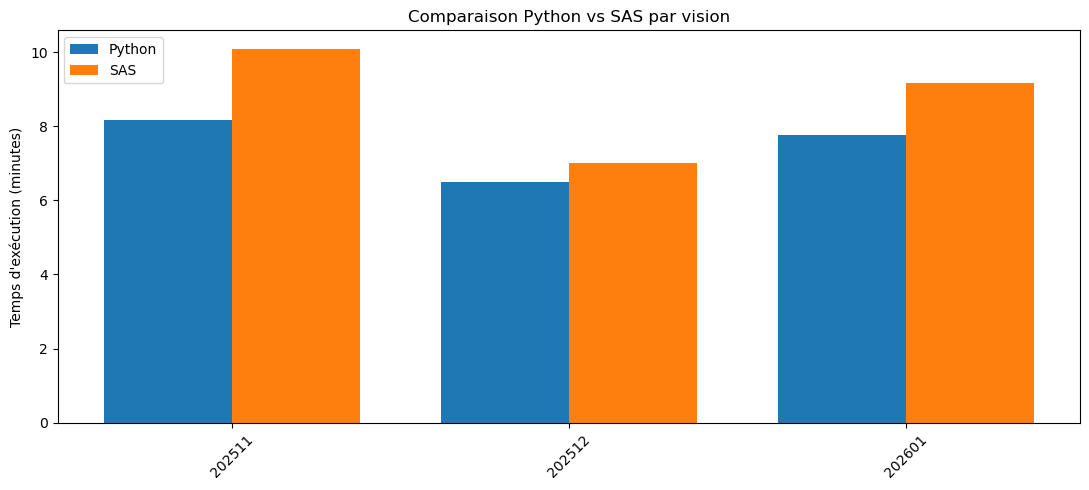

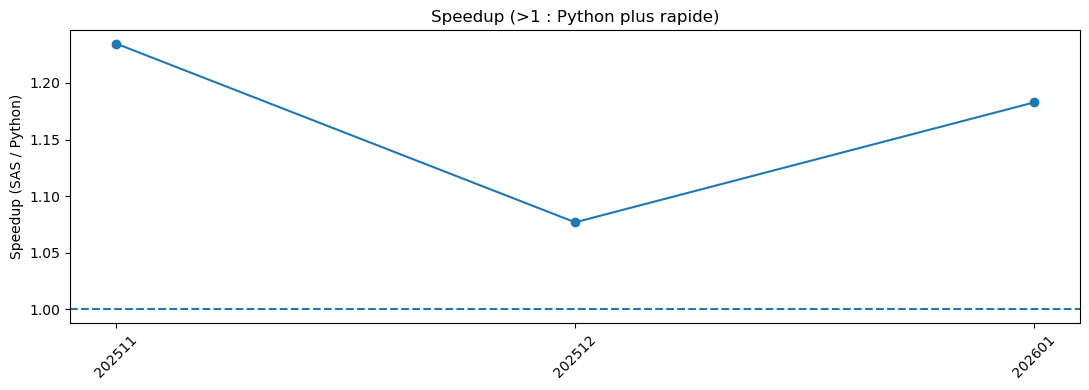

In [45]:
df_plot = df.dropna(subset=["py_min", "sas_min"]).copy()

x = range(len(df_plot))
w = 0.38

# ==============================
# Graphique 1 : Barres groupées
# ==============================
plt.figure(figsize=(11, 5))
plt.bar([i - w/2 for i in x], df_plot["py_min"],  width=w, label="Python")
plt.bar([i + w/2 for i in x], df_plot["sas_min"], width=w, label="SAS")

plt.xticks(list(x), df_plot["vision"], rotation=45)
plt.ylabel("Temps d'exécution (minutes)")
plt.title("Comparaison Python vs SAS par vision")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# Graphique 2 : Speedup
# ==============================
plt.figure(figsize=(11, 4))
plt.plot(df_plot["vision"], df_plot["speedup"], marker="o")
plt.axhline(1.0, linestyle="--")

plt.ylabel("Speedup (SAS / Python)")
plt.title("Speedup (>1 : Python plus rapide)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [46]:
stats = pd.DataFrame({
    "moyenne_min": [df["py_min"].mean(), df["sas_min"].mean()],
    "ecart_type_min": [df["py_min"].std(), df["sas_min"].std()]
}, index=["Python", "SAS"])

# Bonus utile : gain moyen (en minutes et %)
gain_moy_min = stats.loc["SAS", "moyenne_min"] - stats.loc["Python", "moyenne_min"]
gain_moy_pct = (gain_moy_min / stats.loc["SAS", "moyenne_min"]) * 100

stats, gain_moy_min, gain_moy_pct

(        moyenne_min  ecart_type_min
 Python     7.472222        0.867361
 SAS        8.750000        1.583333,
 np.float64(1.2777777777777786),
 np.float64(14.603174603174612))

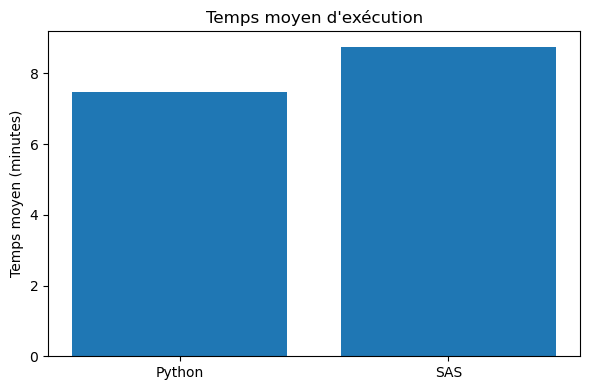

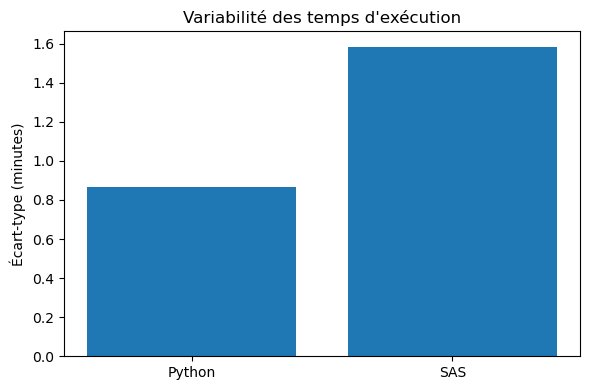

In [47]:
# =========================
# Graphique : Temps moyen
# =========================
plt.figure(figsize=(6, 4))
plt.bar(stats.index, stats["moyenne_min"])
plt.ylabel("Temps moyen (minutes)")
plt.title("Temps moyen d'exécution")
plt.tight_layout()
plt.show()

# =========================
# Graphique : Écart-type
# =========================
plt.figure(figsize=(6, 4))
plt.bar(stats.index, stats["ecart_type_min"])
plt.ylabel("Écart-type (minutes)")
plt.title("Variabilité des temps d'exécution")
plt.tight_layout()
plt.show()

In [48]:
spark.stop()

26/02/18 18:52:36 WARN ExecutorPodsWatchSnapshotSource: Kubernetes client has been closed.
